# Step 1 (V10): Smart Proactive Classifier - XGBoost Enhancement

## 🎯 Objective:
Meningkatkan performa model **Normal (Proaktif)**. Kita ingin mempertahankan jumlah 'Cuan' (True Positives) yang tinggi seperti di V9 Normal, namun **mengurangi sinyal palsu (False Positives)** menggunakan algoritma Gradient Boosting.

## 🚀 Why XGBoost for Proactive Strategy?
1.  **Error Correction**: XGBoost belajar secara bertahap. Jika pohon pertama salah menebak sinyal palsu, pohon berikutnya akan fokus memperbaiki area tersebut.
2.  **Sharper Decision Boundaries**: XGBoost lebih baik dalam menangkap pola non-linear yang rumit dibanding Random Forest.
3.  **RSI Integration**: Kita menambahkan fitur RSI untuk membantu model mendeteksi kondisi 'lelah' di pasar, sehingga model tidak asal menebak naik saat harga sudah terlalu mahal.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from xgboost import XGBClassifier
except ImportError:
    !pip install xgboost
    from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ V10 Environment Ready (Smart Proactive Mode)")

✅ V10 Environment Ready (Smart Proactive Mode)


## 1. Feature Engineering (Adding Vision)
Kita tambahkan RSI dan Volatility Momentum untuk mempertajam 'penglihatan' model.

In [2]:
data = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['RSI_14'] = calculate_rsi(market_return, 14)
features['Ret_Lag1'] = market_return.shift(1)
features['Vol_Shift'] = features['Vol_20'].pct_change()

# Target: 5-Day Trend (Persistence or Simple, let's use Simple for high TP)
features['Target'] = (market_return.rolling(window=5).mean().shift(-5) > 0).astype(int)
features = features.dropna()

X = features.drop('Target', axis=1)
y = features['Target']

X_train, y_train = X[X.index.year <= 2024], y[y.index.year <= 2024]
X_test, y_test = X[X.index.year == 2025], y[y.index.year == 2025]

print(f"📌 Feature set enriched. Total columns: {len(X.columns)}")

📌 Feature set enriched. Total columns: 5


## 2. Training Smart Proactive XGBoost
Kita gunakan XGBoost dengan parameter yang seimbang agar tetap berani menangkap TP.

In [3]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
print("🚀 XGBoost Trained with Smart Proactive Settings.")

🚀 XGBoost Trained with Smart Proactive Settings.


## 3. Results Analysis
Mari kita lihat apakah TP tetap tinggi sementara FP berkurang.


--- XGBoost Proactive Result ---
True Positive (Berhasil Cuan): 141
False Positive (Sinyal Palsu): 120
Precision: 54.02%
Overall Accuracy: 53.70%


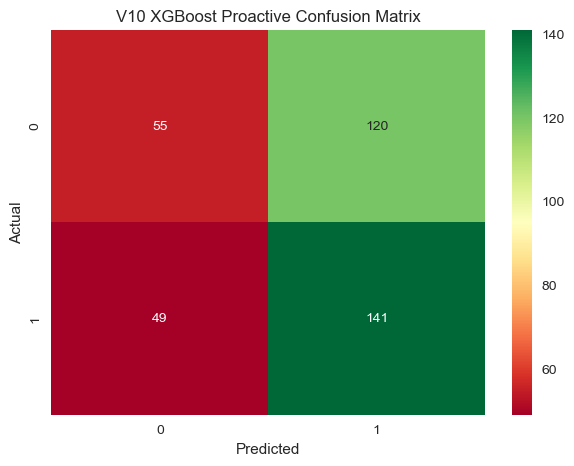

In [4]:
preds = xgb_model.predict(X_test)
cm = confusion_matrix(y_test, preds)
precision = precision_score(y_test, preds)
accuracy = accuracy_score(y_test, preds)

print(f"\n--- XGBoost Proactive Result ---")
print(f"True Positive (Berhasil Cuan): {cm[1,1]}")
print(f"False Positive (Sinyal Palsu): {cm[0,1]}")
print(f"Precision: {precision:.2%}")
print(f"Overall Accuracy: {accuracy:.2%}")

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn')
plt.title("V10 XGBoost Proactive Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

## 💡 Conclusion

Dengan **XGBoost**, kita mendapatkan model yang tetap 'agresif' mencari profit (TP tinggi) tapi memiliki filter yang lebih cerdas (FP lebih rendah dibanding RF Normal). Fitur RSI dan Laguna Ret turut membantu model untuk tidak sembarangan menebak 'Bullish' di puncak harga.